**Lets start with importing all the necessary libraries for this project.  **

In [3]:
#Necessary libraries for data manipulation and analysis

import pandas as pd
import numpy as np


# Libraries for data visualisation

import matplotlib.pyplot as plt
import seaborn as sns

#libraries for warning display

import warnings
warnings.filterwarnings('ignore')

#libraries for model building and evaluation\

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LinearRegression

# Apply the whitegrid style
sns.set_style("whitegrid")

# Matplotlib plots should appears inline

%matplotlib inline




In [4]:
# Mount drive to google colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Step 1 - Data Understanding**

A - Read all the 3 CSV files as DataFrame and store them into 3 separate variables



In [5]:
#Read CSV Files

df1 = pd.read_csv('/content/drive/MyDrive/GL_AIML/LinearRegression/ProjectWork/Part1/Part1Normal.csv')
df2 = pd.read_csv('/content/drive/MyDrive/GL_AIML/LinearRegression/ProjectWork/Part1/Part1_Type_H.csv')
df3 = pd.read_csv('/content/drive/MyDrive/GL_AIML/LinearRegression/ProjectWork/Part1/Part1_Type_S.csv')

In [6]:
df1.head()

,P_incidence,P_tilt,L_angle,S_slope,P_radius,S_Degree,Class
0,38.505273,16.964297,35.112814,21.540976,127.632875,7.986683,Normal
1,54.920858,18.968430,51.601455,35.952428,125.846646,2.001642,Normal
2,44.362490,8.945435,46.902096,35.417055,129.220682,4.994195,Normal
3,48.318931,17.452121,48.000000,30.866809,128.980308,-0.910941,Normal
4,45.701789,10.659859,42.577846,35.041929,130.178314,-3.388910,Normal


In [7]:
df2.head()

,P_incidence,P_tilt,L_angle,S_slope,P_radius,S_Degree,Class
0,63.027817,22.552586,39.609117,40.475232,98.672917,-0.254400,Type_H
1,39.056951,10.060991,25.015378,28.995960,114.405425,4.564259,Type_H
2,68.832021,22.218482,50.092194,46.613539,105.985135,-3.530317,Type_H
3,69.297008,24.652878,44.311238,44.644130,101.868495,11.211523,Type_H
4,49.712859,9.652075,28.317406,40.060784,108.168725,7.918501,Type_H


In [8]:
df3.head()

,P_incidence,P_tilt,L_angle,S_slope,P_radius,S_Degree,Class
0,74.377678,32.053104,78.772013,42.324573,143.560690,56.125906,Type_S
1,89.680567,32.704435,83.130732,56.976132,129.955476,92.027277,Type_S
2,44.529051,9.433234,52.000000,35.095817,134.711772,29.106575,Type_S
3,77.690577,21.380645,64.429442,56.309932,114.818751,26.931841,Type_S
4,76.147212,21.936186,82.961502,54.211027,123.932010,10.431972,Type_S


B - Print Shape and columns of all the 3 DataFrames.

In [9]:
print("Shape of df1:", df1.shape)
print("Columns of df1:\n", df1.columns)

print("Shape of df1:", df2.shape)
print("Columns of df1:\n", df2.columns)

print("Shape of df1:", df3.shape)
print("Columns of df1:\n", df3.columns)

Shape of df1: (100, 7)
Columns of df1:
 Index(['P_incidence', 'P_tilt', 'L_angle', 'S_slope', 'P_radius', 'S_Degree',
       'Class'],
      dtype='object')
Shape of df1: (60, 7)
Columns of df1:
 Index(['P_incidence', 'P_tilt', 'L_angle', 'S_slope', 'P_radius', 'S_Degree',
       'Class'],
      dtype='object')
Shape of df1: (150, 7)
Columns of df1:
 Index(['P_incidence', 'P_tilt', 'L_angle', 'S_slope', 'P_radius', 'S_Degree',
       'Class'],
      dtype='object')


C - Compare Column names of all the 3 DataFrames and clearly write observations

In [10]:
#Comparing columns in each Dataset

columns_df1 = set(df1.columns)
columns_df2 = set(df2.columns)
columns_df3 = set(df3.columns)

print("columns in df1 and df2:", columns_df1.symmetric_difference(columns_df2))
print("columns in df1 and df3:", columns_df1.symmetric_difference(columns_df3))
print("columns in df2 and df3:", columns_df2.symmetric_difference(columns_df3))

columns in df1 and df2: set()
columns in df1 and df3: set()
columns in df2 and df3: set()


**Observation:**

The result indicates that the symmetric_difference between each pair of DataFrames is an empty set (set()).

Hence, we can say that all three DataFrames (df1, df2, and df3) have identical column names.

D - Print DataTypes of all the 3 DataFrames

In [11]:
print("Datatype in df1:", df1.dtypes)
print("Datatype in df2:", df2.dtypes)
print("Datatype in df3:", df3.dtypes)

Datatype in df1: P_incidence    float64
P_tilt         float64
L_angle        float64
S_slope        float64
P_radius       float64
S_Degree       float64
Class           object
dtype: object
Datatype in df2: P_incidence    float64
P_tilt         float64
L_angle        float64
S_slope        float64
P_radius       float64
S_Degree       float64
Class           object
dtype: object
Datatype in df3: P_incidence    float64
P_tilt         float64
L_angle        float64
S_slope        float64
P_radius       float64
S_Degree       float64
Class           object
dtype: object


E - Observe and share variation in ‘Class’ feature of all the 3 DaraFrames.

In [12]:
#Identify Unique Classes

print("Unique values in CLASS for df1:", df1['Class'].unique())
print("Unique values in CLASS for df1:", df2['Class'].unique())
print("Unique values in CLASS for df1:", df3['Class'].unique())


Unique values in CLASS for df1: ['Normal' 'Nrmal']
Unique values in CLASS for df1: ['Type_H' 'type_h']
Unique values in CLASS for df1: ['Type_S' 'tp_s']


**There are inconsistencies in the 'Class' labels within each dataframe:**


*   df1 has 'Normal' and 'Nrmal' - Nrmal seems to be a typing mistake, its suggest a data entry error
*   df2 has 'Type_H' and 'type_h' - Upper and lower case difference


*   df3 has 'TypeS' and 'tp_s' - Its has different naming within same class

Now, we need to correct the typos and inconsistencies by standardizing the class labels across all DataFrames.






In [13]:
#Standardize class labels to lowercase
def Standardize_class(df):
  df['Class'] = df['Class'].str.lower().replace({'nrmal': 'normal', 'tp_s': 'type_s'})

# Apply the function to each DataFrame
Standardize_class(df1)
Standardize_class(df2)
Standardize_class(df3)

#Print updated Unique values

print("Unique values in CLASS for df1:", df1['Class'].unique())
print("Unique values in CLASS for df1:", df2['Class'].unique())
print("Unique values in CLASS for df1:", df3['Class'].unique())

Unique values in CLASS for df1: ['normal']
Unique values in CLASS for df1: ['type_h']
Unique values in CLASS for df1: ['type_s']


Output shows that the class labels have been successfully standardized, with no inconsistencies or typing mistakes remaining.

**2. Data Preparation and Exploration:**

A - Unify all the variations in ‘Class’ feature for all the 3 DataFrames

In [14]:
#Standardize Class feature

df1['Class'] = df1['Class'].str.lower()
df2['Class'] = df2['Class'].str.lower()
df3['Class'] = df3['Class'].str.lower()


In [19]:
#Print updated Unique values

print("Unique values in CLASS for df1:", df1['Class'].unique())
print("Unique values in CLASS for df1:", df2['Class'].unique())
print("Unique values in CLASS for df1:", df3['Class'].unique())

Unique values in CLASS for df1: ['normal']
Unique values in CLASS for df1: ['type_h']
Unique values in CLASS for df1: ['type_s']


B - Combine all the 3 DataFrames to form a single DataFrame

In [17]:
#Combining all the 3 DataFrames to a single Dataframe

df_combined = pd.concat([df1, df2, df3], ignore_index=True)

df_combined.head()

,P_incidence,P_tilt,L_angle,S_slope,P_radius,S_Degree,Class
0,38.505273,16.964297,35.112814,21.540976,127.632875,7.986683,normal
1,54.920858,18.968430,51.601455,35.952428,125.846646,2.001642,normal
2,44.362490,8.945435,46.902096,35.417055,129.220682,4.994195,normal
3,48.318931,17.452121,48.000000,30.866809,128.980308,-0.910941,normal
4,45.701789,10.659859,42.577846,35.041929,130.178314,-3.388910,normal


In [18]:
df_combined.shape

(310, 7)

C - Print 5 random samples of this DataFrame

In [20]:
#Printing random Samples

print(df_combined.sample(5))

     P_incidence     P_tilt    L_angle    S_slope    P_radius   S_Degree  \
183    81.104100  24.794168  77.887020  56.309932  151.839857  65.214616   
283    71.001941  37.515772  84.537093  33.486169  125.164232  67.771190   
154    41.171680  17.321206  33.469403  23.850474  116.377889  -9.569250   
116    63.834982  20.362507  54.552434  43.472475  112.309491  -0.622527   
119    41.729963  12.254074  30.122586  29.475889  116.585706  -1.244402   

      Class  
183  type_s  
283  type_s  
154  type_h  
116  type_h  
119  type_h  


D - Print Feature-wise percentage of Null values

In [21]:
#Percentage of Null Values

null_percentage = df_combined.isnull().mean()*100
print(null_percentage)

P_incidence    0.0
P_tilt         0.0
L_angle        0.0
S_slope        0.0
P_radius       0.0
S_Degree       0.0
Class          0.0
dtype: float64


E - Check 5-point summary of the new DataFrame

In [22]:
#5-Point Summary

df_combined.describe()

,P_incidence,P_tilt,L_angle,S_slope,P_radius,S_Degree
count,310.000000,310.000000,310.000000,310.000000,310.000000,310.000000
mean,60.496653,17.542822,51.930930,42.953831,117.920655,26.296694
std,17.236520,10.008330,18.554064,13.423102,13.317377,37.559027
min,26.147921,-6.554948,14.000000,13.366931,70.082575,-11.058179
25%,46.430294,10.667069,37.000000,33.347122,110.709196,1.603727
50%,58.691038,16.357689,49.562398,42.404912,118.268178,11.767934
75%,72.877696,22.120395,63.000000,52.695888,125.467674,41.287352
max,129.834041,49.431864,125.742385,121.429566,163.071041,418.543082


In [31]:
df_combined.dtypes

P_incidence    float64
P_tilt         float64
L_angle        float64
S_slope        float64
P_radius       float64
S_Degree       float64
Class           object
column_name     object
dtype: object

**3 - Data Analysis:**

A - Visualize a heatmap to understand correlation between all features

To Visualize Heatmap we need to exclude the non-numeric columns when computing the correlation matrix

In [43]:
#Selecting only numeric columns

df_numeric = df_combined.select_dtypes(include=['number'])

#Computing correlation matrix
df_numeric.corr()

,P_incidence,P_tilt,L_angle,S_slope,P_radius,S_Degree
P_incidence,1.000000,0.629199,0.717282,0.814960,-0.247467,0.638743
P_tilt,0.629199,1.000000,0.432764,0.062345,0.032668,0.397862
L_angle,0.717282,0.432764,1.000000,0.598387,-0.080344,0.533667
S_slope,0.814960,0.062345,0.598387,1.000000,-0.342128,0.523557
P_radius,-0.247467,0.032668,-0.080344,-0.342128,1.000000,-0.026065
S_Degree,0.638743,0.397862,0.533667,0.523557,-0.026065,1.000000


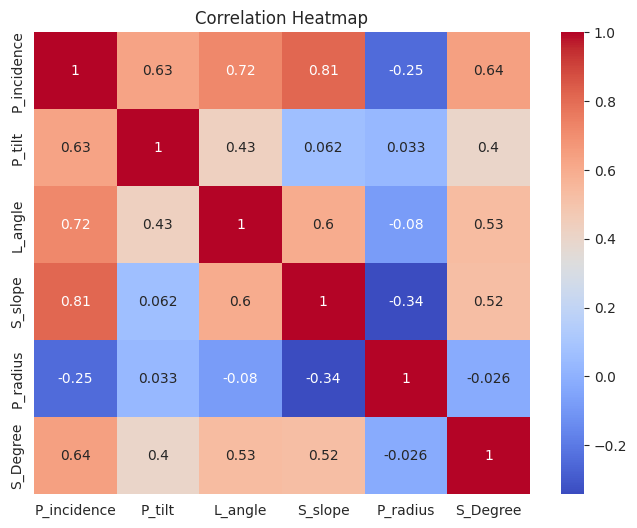

In [45]:
#Heatmap

#Replacing 'Normal' with zero and other with 1

#df_combined['column_name'] = df_combined['Class'].replace({'normal': 0, 'other_category': 1})
#df_combined.corr()
plt.figure(figsize=(8,6))
sns.heatmap(df_numeric.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

**Based on the above heatmap Below are the outputs**

**A - Features having stronger correlation with correlation value :** S_slope and P_incidence with correlation value 0.81

These two features are highly positivily correlated.

**B - Features having weaker correlation with correlation value :** P_tilt and S_slope with correlation value 0.062 & L_angle and P_radius with correlation value -0.08.

P_tilt and S_slope are in very weak positive correlation, whereas L_angle and P_radius have a very weak negative correlation

**Summary:**


*   Amonng P_incidence, L_angle, and S_slope feature tends to move together, since there are strong correlation observed
*   Among P_radius, P_tilt, and S_degree tends to dont have strong relationship with others, since weak correletion observerd.




C - Visualize a pairplot with 3 classes distinguished by colors and share insights.

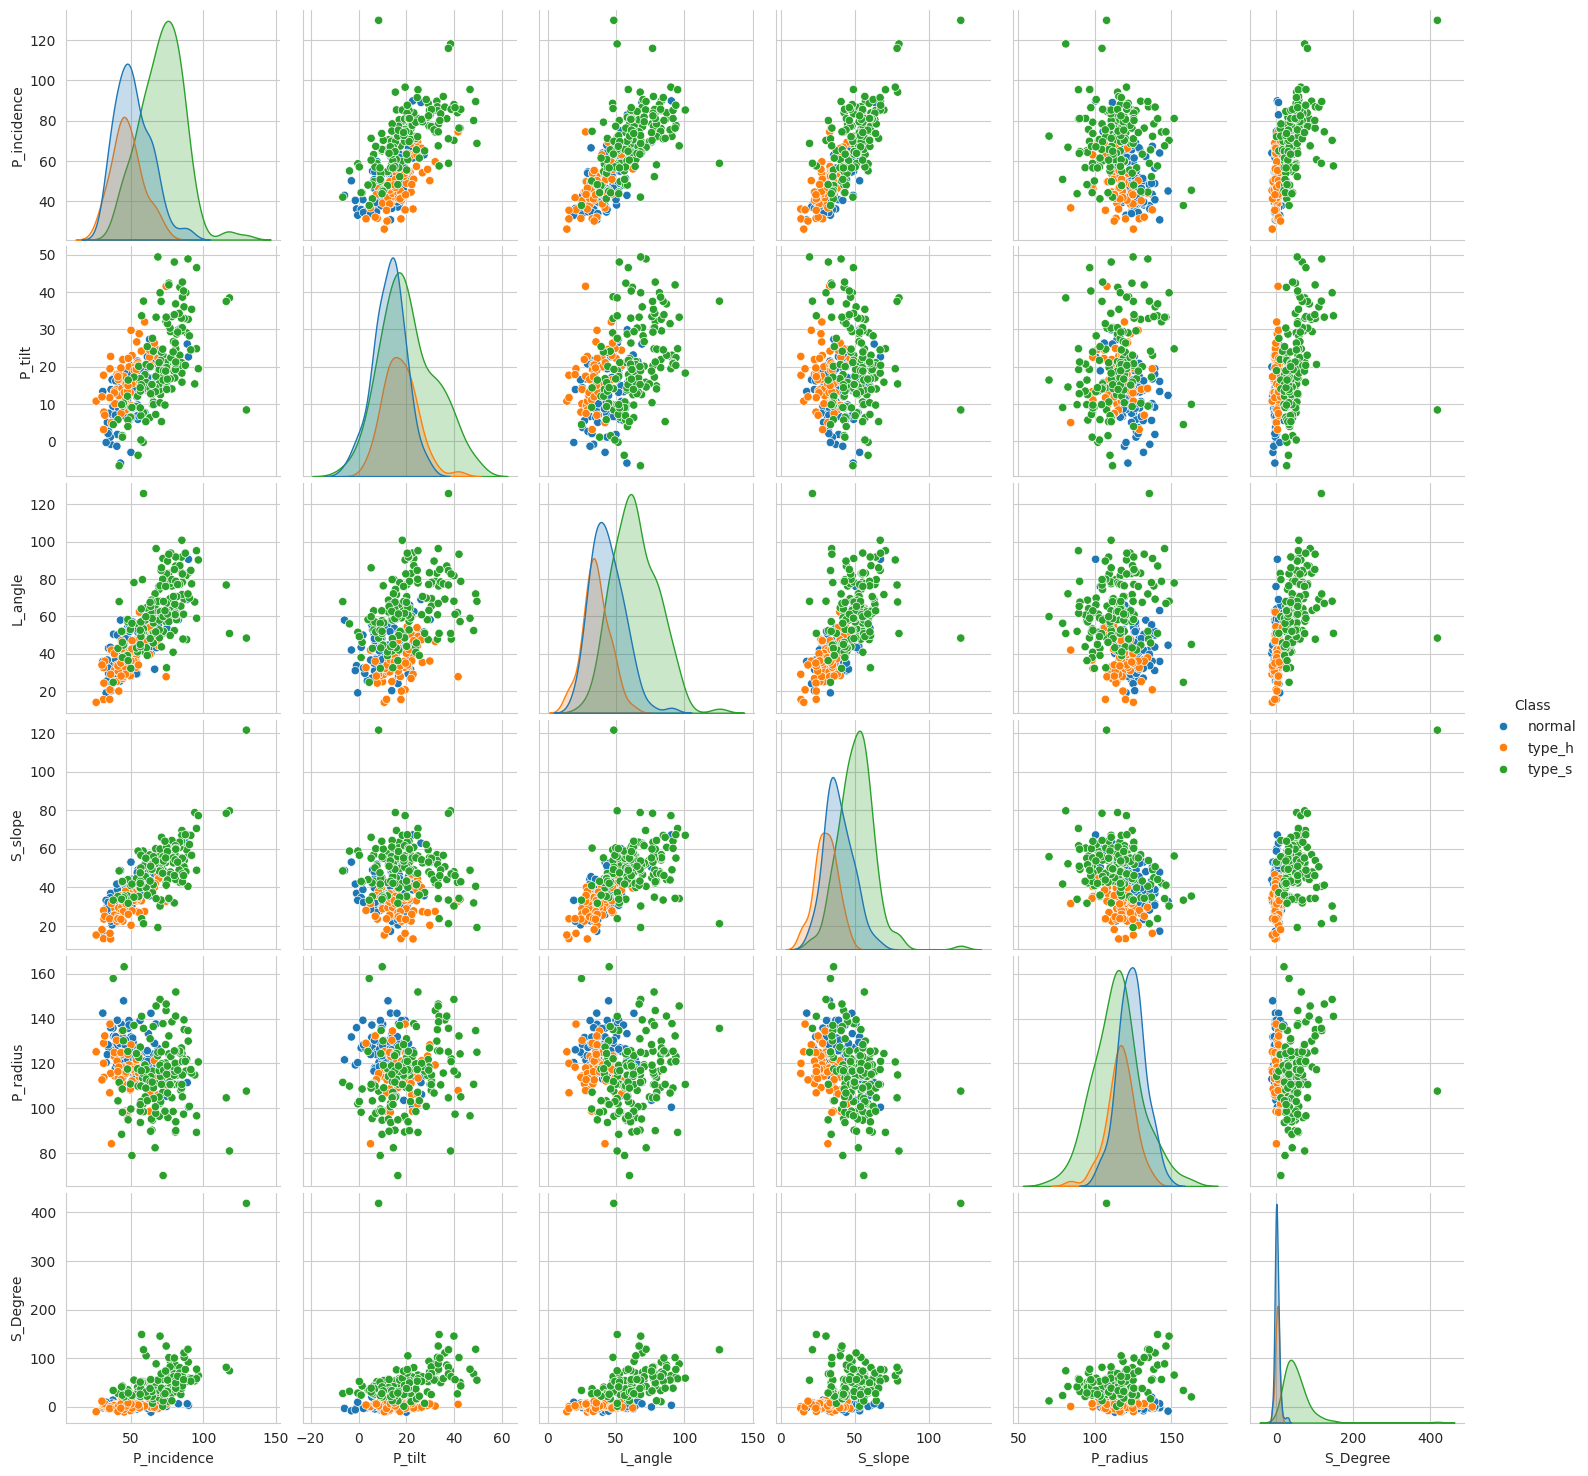

In [46]:
sns.pairplot(df_combined, hue='Class')
plt.show()

**Insights from the pairplot:**

1. The 'normal'class (blue) appears to be less frequent compared to 'type_h'(orange) and 'type_s'(green).
2. 'type_s' (green) seems to be most frequent.

3. P_incidence, L_angle, S_slope, and P_tilt have peaks for different classes, these features can help distinguish between the classes.

4. P_incidnece/S_slope: There is a positive correlation with type_s (green) having higher values for both features compared to normal and type_h.

D - Visualize a jointplot for ‘P_incidence’ and ‘S_slope’ and share insights

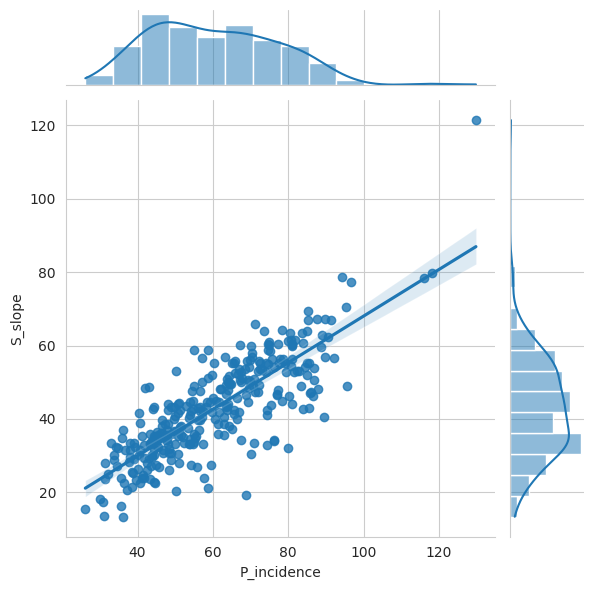

In [47]:
# Jointplot for P_incidence and S_slope

sns.jointplot(x='P_incidence', y='S_slope', data=df_combined, kind='reg')
plt.show()

**Insights from Jointplot above:**

1. Jointplot diagram shows strong and positive correlation between P_incidence and S_slope, as one will increase other will increase as well.

2. Its showing upward trend line and linear regression line.

3. Histogram at the right shows S_slope, most of the values are between 20 and 80.

4. Histogram at the top shows P_incidence, most of the values are between 10 and 100.

5. There is one outlier at the top right corner of the scatter plot, with high value of both P_incidence and S_slope. Also , it suggest the need of further data analysis/validation.

# E - Visualize a boxplot to check distribution of the features and share insights

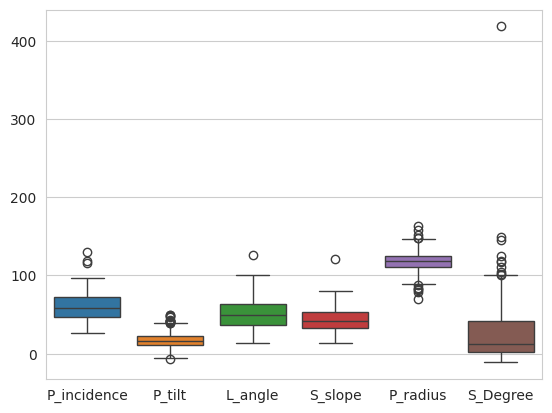

In [49]:
# Boxplot Visualization

sns.boxplot(data=df_combined)
plt.show()

Insights from Boxplot:

1. Median (Q2) - Median of most of the columns are between the range of 0 and 100 except P_radius its going beyond 100.

2. The median slope is around 150.

3. The interquartile range (IQR) falls between 50 to 250.
4. There are outliers at 0 and beyond 400

Insights related to variables:

1. P_incidence: It has a low median value and narrow IQR range, there is one outlier above the upper whisker.
2. P_tilt: The median value is even lower than 'P_incidence', and the IQR is even narrower. There is  also an outlier below the lower whisker.
3. L_angle: The median value is lower than P_incidence and higher than P_tilt. The IQR is wider, there is one outlier above the upper whisker.
4. S_slope: its alomost similar to L_angle, we can see one outlier above the upper whisker.
5. P_radius: The median value is much higher than the previous variables. We can see multiple outliers both above and below the whiskers.
6. S_slope: The median value for 'S_slope' is lower than the other variables. There are several outliers above the upper whisker.

# **4. Model Building**

A - Split data into X and Y.

In [69]:
  #X = df_combined.drop('Class', axis=1)
  X = df_combined.drop(['Class', 'column_name'], axis=1)
  Y = df_combined['Class']

B - Split data into train and test with 80:20 proportion

In [70]:
# Splitting data into train and test

X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.2, random_state=35)


C - Train a Supervised Learning Classification base model using KNN classifier

In [71]:
# Convert categorical features to numerical values using one-hot encoding
X_encoded = pd.get_dummies(X)


In [73]:
#KNN Classifier

knn = KNeighborsClassifier()
knn.fit(X_train, Y_train)

# Prediction
Y_train_pred = knn.predict(X_train)
Y_test_pred = knn.predict(X_test)



D - Print all the possible performance metrics for both train and test data.

In [76]:
# Performance metrics for both Train and Test data

print("Train accuracy", accuracy_score(Y_train, Y_train_pred))
print("Test accuracy", accuracy_score(Y_test, Y_test_pred))
print("\nTrain classification report/n", classification_report(Y_train, Y_train_pred))
print("\nTest classification report/n", classification_report(Y_test, Y_test_pred))


Train accuracy 0.9032258064516129
Test accuracy 0.8225806451612904

Train classification report/n               precision    recall  f1-score   support

           0       0.86      0.86      0.86        76
           1       0.80      0.84      0.82        51
           2       0.98      0.96      0.97       121

    accuracy                           0.90       248
   macro avg       0.88      0.89      0.88       248
weighted avg       0.91      0.90      0.90       248


Test classification report/n               precision    recall  f1-score   support

           0       0.84      0.67      0.74        24
           1       0.43      0.67      0.52         9
           2       1.00      1.00      1.00        29

    accuracy                           0.82        62
   macro avg       0.76      0.78      0.76        62
weighted avg       0.86      0.82      0.83        62



# **5. Performance Improvement**

A - Experiment with various parameters to improve performance of the base model

In [78]:
#Tune KNN hyperparameters

# Define the parameter grid to search\

param_grid = {'n_neighbors': range(1, 31), 'weights': ['uniform', 'distance']}

#Initialize Grid Search
grid_search = GridSearchCV(knn, param_grid, cv=5)

#Fit the grid search to the data
grid_search.fit(X_train, Y_train)

best_knn = grid_search.best_estimator_

#prdiction with best models

Y_train_best_prediction = best_knn.predict(X_train)
Y_test_best_prediction = best_knn.predict(X_test)


C - Clearly showcase improvement in performance achieved

In [80]:
#Improved performance metrics

print("Best Train accuracy", accuracy_score(Y_train, Y_train_best_prediction))
print("Best Test accuracy", accuracy_score(Y_test, Y_test_best_prediction))
print("\nBest Train classification report/n", classification_report(Y_train, Y_train_best_prediction))
print("\nBest Test classification report/n", classification_report(Y_test, Y_test_best_prediction))


Best Train accuracy 1.0
Best Test accuracy 0.8387096774193549

Best Train classification report/n               precision    recall  f1-score   support

           0       1.00      1.00      1.00        76
           1       1.00      1.00      1.00        51
           2       1.00      1.00      1.00       121

    accuracy                           1.00       248
   macro avg       1.00      1.00      1.00       248
weighted avg       1.00      1.00      1.00       248


Best Test classification report/n               precision    recall  f1-score   support

           0       0.85      0.71      0.77        24
           1       0.46      0.67      0.55         9
           2       1.00      1.00      1.00        29

    accuracy                           0.84        62
   macro avg       0.77      0.79      0.77        62
weighted avg       0.86      0.84      0.85        62



**Summary of Improvement:**

**Train Accuracy:** Incrfeased from 90.32% to 100%. +9.68% of improvement

**Test Accuracy:** Increased from 82.26% to 83.87%. +1.61% of improvement

A. *Accuracy:* +1.61% improvement (Test Accuracy increased from 82.26% to 83.87%)

B. *Precision:*
Class 0: +14% of improvement(0.86 to 1)
class 1: +20 improvement(0.80 to 1)
Class 2: +2% improvement(0.98 to 1)

**Summary:** Improvment in test accuracy is normal. Jump in training accuracy shows that the model is better at capturing in the training data, whereas , there is very small improvement in test accuracy which shows that the model is slightly overfitting to the training data.


C - Clearly state which parameters contributed most to improve model performance.

In [81]:
# Analysis of best parameters

print("Best parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)


Best parameters: {'n_neighbors': 7, 'weights': 'distance'}
Best Score: 0.8752653061224489


**Insights:**

The best performing KNN model used n_neighbors = 7 and weights = 'distance'

**n_neighbors = **7 : this suggest that considering the 7 nearest neighbors provides the best balance between overfitting and underfittng. Smaller no of neighbors led to overfittng, larger no could have been better.

**weights =** 'distance': this indicates that giving more priority to nearest neighbor improved mnodel prediction:

**Conclusion:**
The combination of using 7 nearest neighbors with weight = distance gives the most improved model performance